# Класифікація кредитного ризику (Logistic Regression та SVM)

У цій роботі я побудую пайплайн бінарної класифікації для вирішення задачі — класифікації кредитного ризику. Я застосую два алгоритми: Logistic Regression та SVM з лінійним та нелінійними ядрами.
##### Про датасет
Для роботи я обрав German Credit Dataset — набір даних для машинного навчання, який я завантажую з репозиторію OpenML.
##### Суть задачі:
Банк має історичні дані про 1000 клієнтів (їхній вік, кредитну історію, мету кредиту, розмір депозиту тощо). Кожен клієнт має мітку:

* good — повернув кредит без проблем.

* bad — мав проблеми з поверненням кредиту.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# dataload
credit = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = credit.frame

display(df.head())
print(df.shape)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


(1000, 21)


In [3]:
print(df.shape)

(1000, 21)


готую дані, щоб їх можна було використовувати в моделі.

для того щоб метрики показували те що мені корисно беру ризикованих клієнтів за "1", а безпечних за "0", оскільки мені цінніше детектить клієнтів які не виплатять кредит як тих що візьмуть і виплатять.

In [9]:
y = credit.target.map({'bad': 1, 'good': 0}).astype(int)

if 'class' in df.columns:
    X_raw = df.drop('class', axis=1)
else:
    X_raw = df

X = pd.get_dummies(X_raw, drop_first=True)

print(X.shape)

(1000, 48)


C:\Users\LEGION 5 PRO\AppData\Local\Temp\ipykernel_8028\2143635171.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['0 (Надійний)', '1 (Ризикований)'])


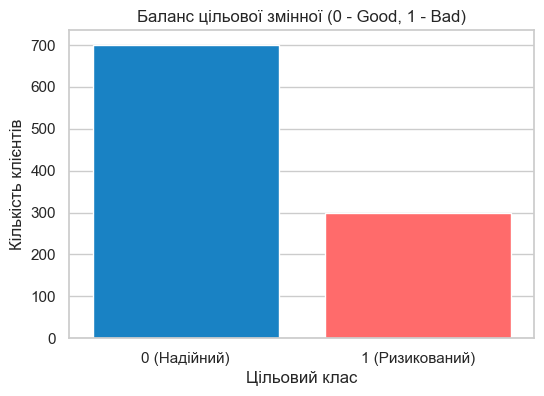

In [14]:
# візуалізація збалансованості данних
plt.figure(figsize=(6, 4))

colors = ['#1982c4', '#ff6b6b']
ax = sns.countplot(x=y)
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)
ax.set_title("Баланс цільової змінної (0 - Good, 1 - Bad)")
ax.set_xlabel("Цільовий клас")
ax.set_ylabel("Кількість клієнтів")
ax.set_xticklabels(['0 (Надійний)', '1 (Ризикований)'])

plt.show()

є дизбаланс в данних тому на accuracy увагу не звертаю

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

In [27]:
# Пайплайн для Логістичної регресії
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Пайплайн для SVM з RBF-ядром
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42, probability=True))
])

In [22]:
pipeline_lr.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(probability=True, random_state=42))])

In [23]:
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_svm = pipeline_svm.predict(X_test)

In [26]:
metrics_df = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

def evaluate_model(y_true, y_pred, model, X_test, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_true, y_proba)
    
    metrics_df.loc[model_name] = [accuracy, precision, recall, f1, roc_auc]

evaluate_model(y_test, y_pred_lr, pipeline_lr, X_test, 'Logistic Regression')
evaluate_model(y_test, y_pred_svm, pipeline_svm, X_test, 'SVM (RBF)')

display(metrics_df.round(3))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.772,0.645,0.533,0.584,0.799
SVM (RBF),0.772,0.688,0.440,0.537,0.808


на мії погляд обидві моделі далекі від ідеалу, але все ж кращі ніж рандомне вгадування.

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)
print("Найкращі параметри LogReg:", grid_lr.best_params_)

Найкращі параметри LogReg: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


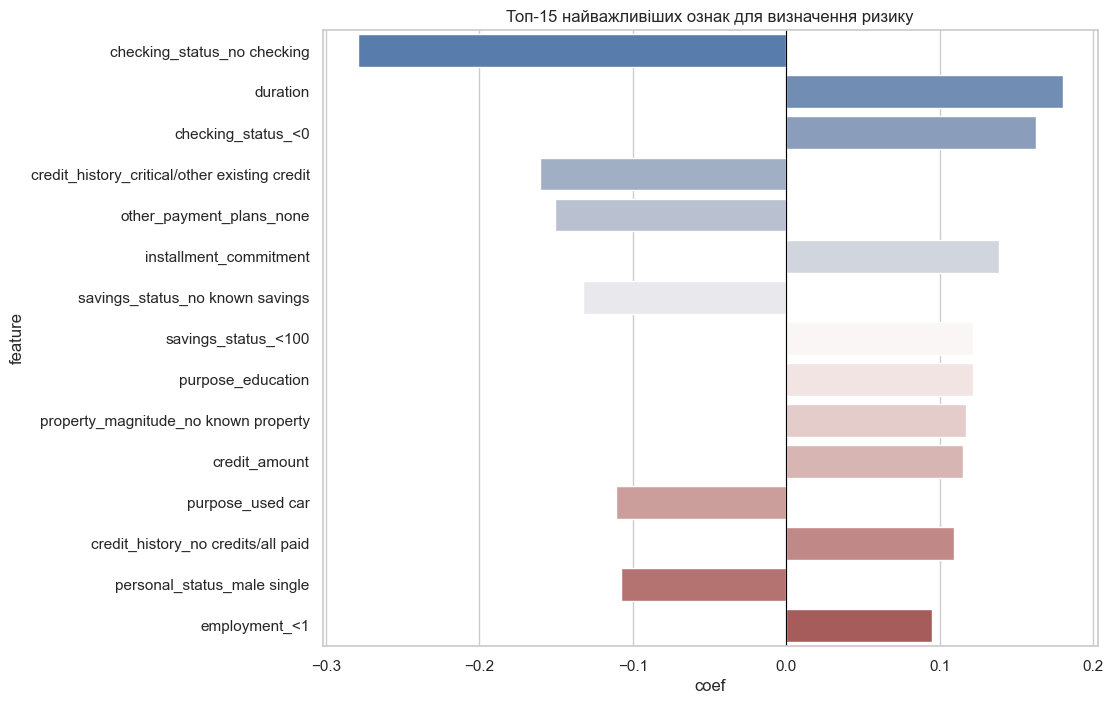

In [37]:
best_lr_model = grid_lr.best_estimator_.named_steps['model']
features = X.columns

coef_df = pd.DataFrame({'feature': features, 'coef': best_lr_model.coef_[0]})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='coef', y='feature', hue='feature', palette='vlag', legend=False)
plt.title("Топ-15 найважливіших ознак для визначення ризику")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

Аналіз коефіцієнтів логістичної регресії показав, що найважливішим фактором ризику є тривалість кредиту (duration): чим вона більша, тим вища ймовірність неповернення. Натомість відсутність проблем з поточним рахунком (checking_status_no checking) є головним індикатором надійності клієнта.

In [38]:
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__gamma': [0.1, 0.01, 0.001],
    'model__kernel': ['rbf']
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
print("Найкращі параметри SVM:", grid_svm.best_params_)

Найкращі параметри SVM: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


порівняю метрики з найкращими параметрами від GridSearch

In [41]:
best_lr_grid = grid_lr.best_estimator_
best_svm_grid = grid_svm.best_estimator_

y_pred_lr_opt = best_lr_grid.predict(X_test)
y_probs_lr_opt = best_lr_grid.predict_proba(X_test)[:, 1]

y_pred_svm_opt = best_svm_grid.predict(X_test)
y_probs_svm_opt = best_svm_grid.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_probs):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        roc_auc_score(y_true, y_probs)
    ]

final_comparison = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
final_comparison.loc['LogReg '] = get_metrics(y_test, y_pred_lr_opt, y_probs_lr_opt)
final_comparison.loc['SVM '] = get_metrics(y_test, y_pred_svm_opt, y_probs_svm_opt)

display(final_comparison.round(3))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
LogReg,0.760,0.615,0.533,0.571,0.799
SVM,0.768,0.673,0.440,0.532,0.805


C:\AnacondCamp\envs\local_env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\AnacondCamp\envs\local_env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


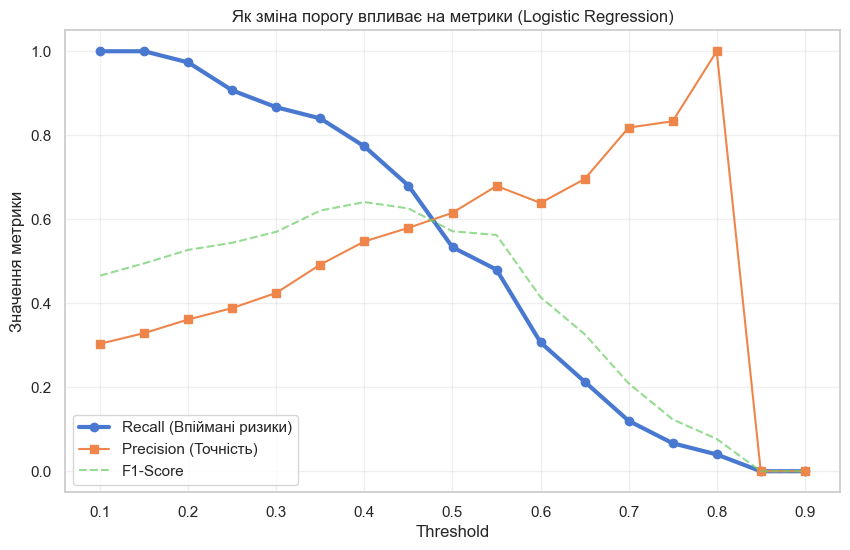

In [45]:
def plot_threshold_impact(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    
    thresholds = np.arange(0.1, 0.95, 0.05)
    results = []
    
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        results.append({
            'Threshold': t,
            'Recall': recall_score(y_test, y_pred_t),
            'Precision': precision_score(y_test, y_pred_t),
            'F1': f1_score(y_test, y_pred_t),
            'Accuracy': accuracy_score(y_test, y_pred_t)
        })
    
    df_res = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_res['Threshold'], df_res['Recall'], label='Recall (Впіймані ризики)', marker='o', linewidth=3)
    plt.plot(df_res['Threshold'], df_res['Precision'], label='Precision (Точність)', marker='s')
    plt.plot(df_res['Threshold'], df_res['F1'], label='F1-Score', linestyle='--', alpha=0.7)
    
    plt.title('Як зміна порогу впливає на метрики (Logistic Regression)')
    plt.xlabel('Threshold')
    plt.ylabel('Значення метрики')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df_res

threshold_results = plot_threshold_impact(best_lr_grid, X_test, y_test)

по данному графіку залежності метрик від порогу роблю висновок що "ідеальний" поріг для данної задачі з використанням LogisticRegression був би 0.3-0.4. так як найважливішим тут буде високий Recall, при цьому інші метрики не сильно просідають.

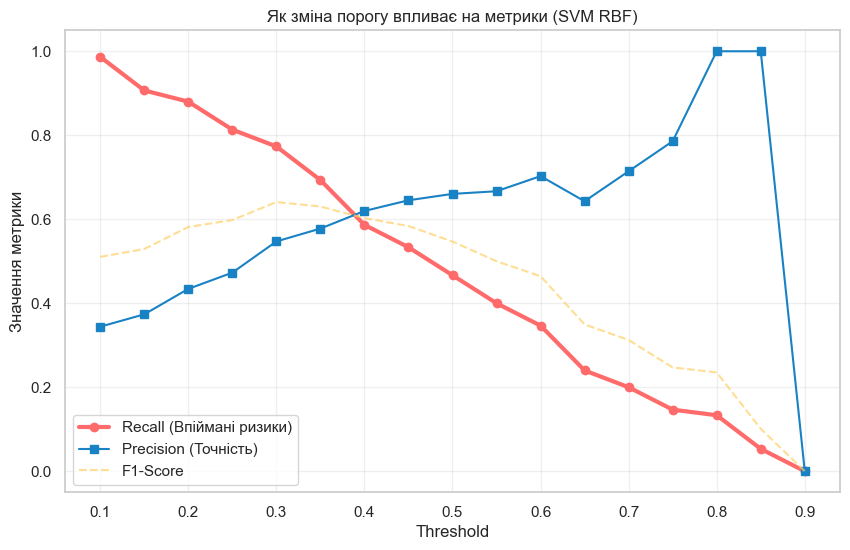

,Threshold,Recall,Precision,F1,Accuracy
0,0.10,0.987,0.344,0.510,0.432
1,0.15,0.907,0.374,0.529,0.516
2,0.20,0.880,0.434,0.581,0.620
3,0.25,0.813,0.473,0.598,0.672
4,0.30,0.773,0.547,0.641,0.740
5,0.35,0.693,0.578,0.630,0.756
6,0.40,0.587,0.620,0.603,0.768
7,0.45,0.533,0.645,0.584,0.772
8,0.50,0.467,0.660,0.547,0.768
9,0.55,0.400,0.667,0.500,0.760


In [48]:
def plot_threshold_impact_svm(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    
    thresholds = np.arange(0.1, 0.95, 0.05)
    results = []
    
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        results.append({
            'Threshold': t,
            'Recall': recall_score(y_test, y_pred_t, zero_division=0),
            'Precision': precision_score(y_test, y_pred_t, zero_division=0),
            'F1': f1_score(y_test, y_pred_t, zero_division=0),
            'Accuracy': accuracy_score(y_test, y_pred_t)
        })
    
    df_res = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_res['Threshold'], df_res['Recall'], label='Recall (Впіймані ризики)', color='#ff6b6b', marker='o', linewidth=3)
    plt.plot(df_res['Threshold'], df_res['Precision'], label='Precision (Точність)', color='#1982c4', marker='s')
    plt.plot(df_res['Threshold'], df_res['F1'], label='F1-Score', color='#ffd166', linestyle='--', alpha=0.7)
    
    plt.title('Як зміна порогу впливає на метрики (SVM RBF)')
    plt.xlabel('Threshold')
    plt.ylabel('Значення метрики')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df_res

svm_threshold_results = plot_threshold_impact_svm(grid_svm.best_estimator_, X_test, y_test)

display(svm_threshold_results.round(3))

такий самий графік для моделі SVM, тут я б взяв поріг 0.25-0.3, а загалом для цієї задачі я б вибрав логістичну регресію бо там recall вище при оптимальних precission, f1. 